# Primary Model

## Purged Validation

- **Purpose:** Apply `purged_validation.py`'s `PurgedKFold` directly to the development partition.
- **Settings:** `cv=5` contiguous folds; `pct_embargo=0.01`; `random_state=42`; labels = {-1, 1}; sealed chronological holdout.
- **Data:** Use development features, direction labels, sample weights, and event information intervals.
- **Findings:**
- **Decision:** Purge overlapping intervals, exclude holdout from every fold, and minimize weighted log loss with weighted F1 used only for exact ties.

In [1]:
from pathlib import Path

from IPython import get_ipython

get_ipython().run_line_magic("matplotlib", "inline")

import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parents[2]

from src.modeling.purged_validation import PurgedKFold
from src.modeling.model_workflow import (
    build_model_evaluation_table,
    build_primary_model_frame,
    compute_stage_importance,
    finalize_primary_model,
    get_primary_feature_columns,
    plot_feature_importance,
    plot_learning_curves,
    plot_model_evaluation,
    run_model_selection_workflow,
)
from src.preprocessing.market_data import ResearchPaths

RANDOM_STATE = 42
CV_SPLITS = 5
PCT_EMBARGO = 0.01
TRAIN_SIZES = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
PERIOD = "2025-02-01_2025-12-31"
PARAMETER_GRIDS = {
    "boosting": {
        "model__n_estimators": [100, 200],
        "model__estimator__max_depth": [2, 5],
        "model__learning_rate": [0.03, 0.1],
    },
    "bagging": {
        "model__n_estimators": [100, 200],
        "model__estimator__max_depth": [2, 5],
        "model__max_samples": [0.4, 0.8],
        "model__max_features": [0.4, 0.8],
    },
    "random_forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [2, 5],
        "model__max_samples": [0.4, 0.8],
        "model__max_features": [0.1, 0.2],
    },
}
paths = ResearchPaths(PROJECT_ROOT, model_kind="sentiment", period=PERIOD)
event_path = paths.event("model")
artifact_dir = PROJECT_ROOT / "data/modeling/sentiment"
artifact_dir.mkdir(parents=True, exist_ok=True)

events = pd.read_parquet(event_path).sort_values("event_start", ignore_index=True)
development_starts = events.loc[
    events["partition"].eq("development"), ["symbol", "event_start"]
]
holdout_starts = events.loc[
    events["partition"].eq("holdout"), ["symbol", "event_start"]
]
development = build_primary_model_frame(events, development_starts, model_kind="sentiment")
holdout = build_primary_model_frame(events, holdout_starts, model_kind="sentiment")
feature_columns = get_primary_feature_columns(development, model_kind="sentiment")

X_development = development[feature_columns]
y_development = development["direction_label"].astype("int8")
w_development = development["sample_weight"].astype("float64")
t1_development = development["event_end"]
CLASS_LABELS = [-1, 1]
STAGE_SCORING = "neg_log_loss"

cv = PurgedKFold(CV_SPLITS, t1=t1_development, pct_embargo=PCT_EMBARGO)
fold_assignment = pd.Series(pd.NA, index=X_development.index, dtype="Int64", name="cv_fold")
fold_rows = []
for fold, (train, test) in enumerate(cv.split(X_development)):
    fold_assignment.iloc[test] = fold
    fold_rows.append({
        "fold": fold,
        "train_events": len(train),
        "test_events": len(test),
        "test_start": t1_development.index.get_level_values("event_start")[test].min(),
        "test_end": t1_development.iloc[test].max(),
    })

split_manifest = events[[
    "symbol", "event_start", "event_end", "partition", "holdout_boundary"
]].merge(
    fold_assignment.reset_index(),
    on=["symbol", "event_start"],
    how="left",
    validate="one_to_one",
)
split_manifest.to_parquet(artifact_dir / "split_manifest.parquet", index=False)
display(pd.DataFrame(fold_rows).set_index("fold"))
display(pd.Series({
    "development_events": len(development),
    "holdout_events": len(holdout),
    "features": len(feature_columns),
}, name="value").to_frame())

,train_events,test_events,test_start,test_end
fold,,,,
0,11344,2882,2025-02-03 14:30:00.009395+00:00,2025-04-02 16:54:06.660953+00:00
1,11027,2882,2025-04-02 14:13:38.147152+00:00,2025-05-06 18:38:13.769528+00:00
2,11290,2881,2025-05-02 13:30:03.066935+00:00,2025-07-10 16:38:14.868445+00:00
3,11335,2881,2025-07-10 14:37:39.034456+00:00,2025-09-03 17:45:21.507708+00:00
4,11515,2881,2025-09-03 13:30:00.864600+00:00,2025-10-24 13:50:57.771170+00:00


,value
development_events,14407
holdout_events,3565
features,50


## Ensemble Methods

- **Purpose:** Compare all AdaBoost, Bagging, and Random Forest configurations and select the best candidate per family and overall.
- **Settings:** Notebook-owned grids: 27 AdaBoost, 81 Bagging, 81 RF configurations; max_depth=[2, 5, 10] for all families; library-default leaf size; AdaBoost class_weight=None, Bagging class_weight=balanced, RF class_weight=balanced_subsample; entropy trees; cv=5; embargo 1%; seed 42; n_jobs=1; OOB disabled.
- **Data:** Generate sample-weighted purged development OOF predictions for every configuration; display the full search and family winners.
- **Findings:**
- **Decision:** Select by minimum weighted OOF log loss, then maximum weighted F1; exact ties retain family and grid order. Holdout remains excluded.


In [2]:
selection_result = run_model_selection_workflow(
    X_development,
    y_development,
    w_development,
    t1_development,
    scoring=STAGE_SCORING,
    cv=CV_SPLITS,
    pct_embargo=PCT_EMBARGO,
    random_state=RANDOM_STATE,
    n_jobs=1,
    candidate_settings={name: {} for name in PARAMETER_GRIDS},
    parameter_grids=PARAMETER_GRIDS,
    show_progress=True,
)
candidates = selection_result.estimators
candidate_oof = selection_result.oof_predictions
final_name = selection_result.selected_name
final_configuration = selection_result.final_configuration
final_estimator = selection_result.final_estimator
final_oof = selection_result.final_oof
display(selection_result.tuning)
display(selection_result.comparison.rename(index=lambda name: name.replace("_", " ").title()))
print(f"Selected family: {final_name}; configuration: {final_configuration}")


Ensemble search:   0%|          | 0/200 [00:00<?, ?it/s]

,candidate,configuration,model__estimator__max_depth,model__learning_rate,model__n_estimators,log_loss,accuracy,f1,precision,recall,model__max_features,model__max_samples,model__max_depth
0,boosting,"{'model__estimator__max_depth': 2, 'model__lea...",2.0,0.03,100,0.722805,0.614955,0.620086,0.597824,0.644069,NaN,NaN,NaN
1,boosting,"{'model__estimator__max_depth': 2, 'model__lea...",2.0,0.03,200,0.696729,0.615375,0.620522,0.598213,0.644560,NaN,NaN,NaN
2,boosting,"{'model__estimator__max_depth': 2, 'model__lea...",2.0,0.10,100,0.681824,0.615331,0.617365,0.599736,0.636062,NaN,NaN,NaN
3,boosting,"{'model__estimator__max_depth': 2, 'model__lea...",2.0,0.10,200,0.670856,0.614962,0.618822,0.598465,0.640612,NaN,NaN,NaN
4,boosting,"{'model__estimator__max_depth': 5, 'model__lea...",5.0,0.03,100,0.709556,0.612207,0.613744,0.596967,0.631490,NaN,NaN,NaN
5,boosting,"{'model__estimator__max_depth': 5, 'model__lea...",5.0,0.03,200,0.685914,0.609379,0.611192,0.594103,0.629293,NaN,NaN,NaN
6,boosting,"{'model__estimator__max_depth': 5, 'model__lea...",5.0,0.10,100,0.677339,0.609561,0.608965,0.595422,0.623139,NaN,NaN,NaN
7,boosting,"{'model__estimator__max_depth': 5, 'model__lea...",5.0,0.10,200,0.675275,0.606763,0.606281,0.592627,0.620579,NaN,NaN,NaN
8,bagging,"{'model__estimator__max_depth': 2, 'model__max...",2.0,NaN,100,0.662720,0.613581,0.611429,0.600145,0.623144,0.4,0.4,NaN
9,bagging,"{'model__estimator__max_depth': 2, 'model__max...",2.0,NaN,200,0.662431,0.614742,0.612267,0.601460,0.623469,0.4,0.4,NaN


,configuration,model__estimator__max_depth,model__learning_rate,model__n_estimators,log_loss,accuracy,f1,precision,recall,model__max_features,model__max_samples,model__max_depth
candidate,,,,,,,,,,,,
Boosting,"{'model__estimator__max_depth': 2, 'model__lea...",2.0,0.1,200,0.670856,0.614962,0.618822,0.598465,0.640612,NaN,NaN,NaN
Bagging,"{'model__estimator__max_depth': 2, 'model__max...",2.0,NaN,200,0.662431,0.614742,0.612267,0.601460,0.623469,0.4,0.4,NaN
Random Forest,"{'model__max_depth': 2, 'model__max_features':...",NaN,NaN,200,0.661509,0.615115,0.622087,0.597064,0.649298,0.2,0.8,2.0


Selected family: random_forest; configuration: {'model__max_depth': 2, 'model__max_features': 0.2, 'model__max_samples': 0.8, 'model__n_estimators': 200}


## Learning Curves

- **Purpose:** Diagnose each family's best estimator with the same weighted learning-curve helper.
- **Settings:** `train_sizes=(0.10,0.20,...,1.00); 10 points; 1x3 layout`; stratified subsets; `cv=5`; embargo 1%; seed 42; error = weighted log loss, mean ± standard error.
- **Data:** Build each family winner's learning curve from development folds only.
- **Findings:**
- **Decision:** Do not revise the model or grid from holdout learning behavior.

Learning curves:   0%|          | 0/150 [00:00<?, ?it/s]

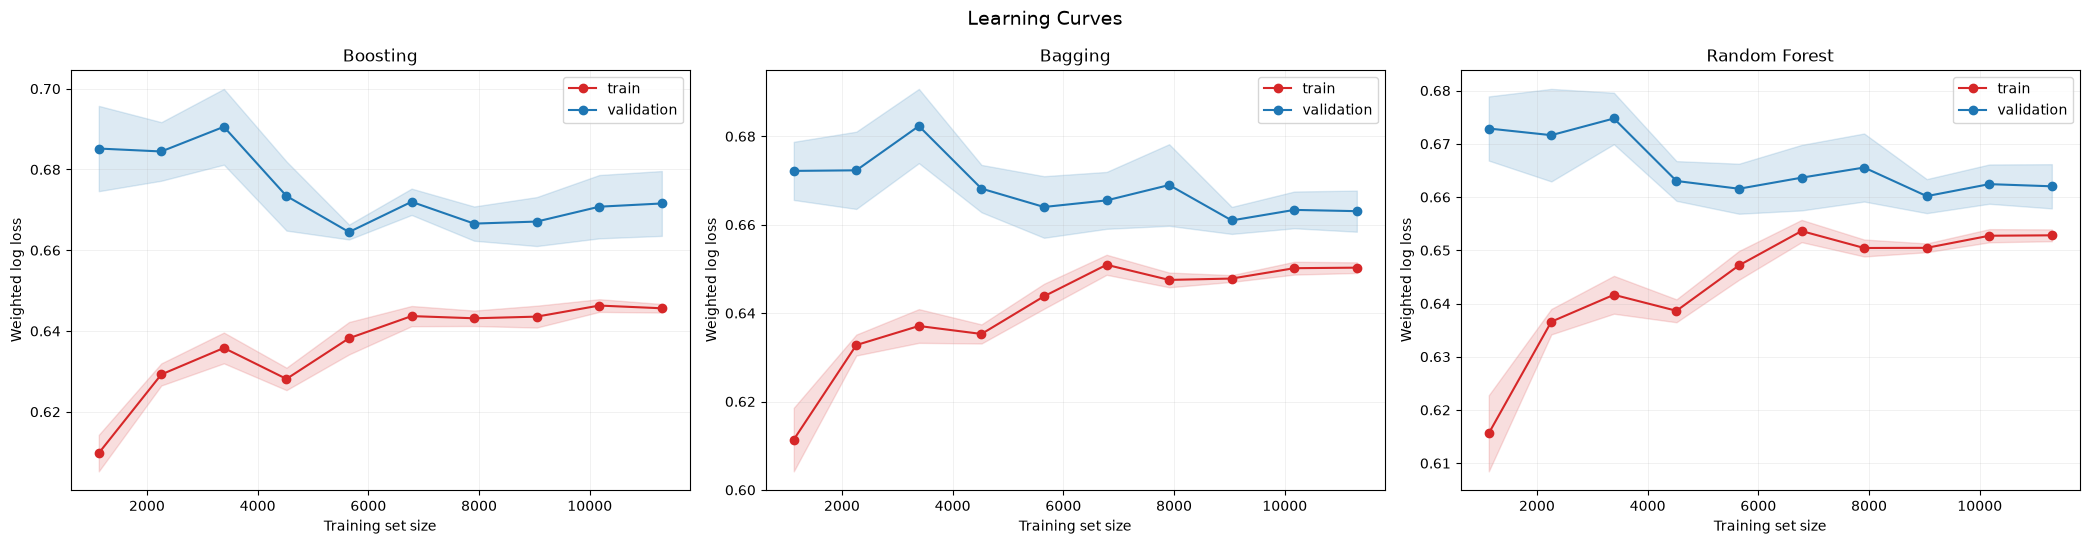

{'boosting':    train_fraction  train_size  train_error_mean  train_error_std  \
 0             0.1        1130          0.609761         0.004524   
 1             0.2        2260          0.629242         0.002742   
 2             0.3        3390          0.635802         0.003816   
 3             0.4        4521          0.628133         0.002780   
 4             0.5        5651          0.638208         0.004015   
 5             0.6        6781          0.643692         0.002505   
 6             0.7        7911          0.643152         0.001911   
 7             0.8        9042          0.643560         0.002706   
 8             0.9       10172          0.646303         0.001575   
 9             1.0       11302          0.645627         0.001061   
 
    validation_error_mean  validation_error_std  
 0               0.685189              0.010564  
 1               0.684464              0.007256  
 2               0.690574              0.009385  
 3               0.673428  

In [3]:
plot_learning_curves(
    candidates,
    "Learning Curves",
    features=X_development,
    labels=y_development,
    sample_weight=w_development,
    cv=cv,
    train_sizes=TRAIN_SIZES,
    class_labels=CLASS_LABELS,
    positive_label=1,
    scoring=STAGE_SCORING,
    random_state=RANDOM_STATE,
    show_progress=True,
)

## Feature Importance

- **Purpose:** Apply the same estimator-aware MDI, MDA, and SFI methods to each family’s best candidate.
- **Settings:** `cv=5`; `pct_embargo=0.01`; `random_state=42`; `top_k=15`; MDI/MDA/SFI in one row per family; MDA and SFI use weighted negative log loss.
- **Data:** Calculate and preserve family-winner importance results for all 50 primary features.
- **Findings:**
- **Decision:** Treat importance as a diagnostic rather than feature selection.

MDI importance:   0%|          | 0/6 [00:00<?, ?it/s]

MDA importance:   0%|          | 0/255 [00:00<?, ?it/s]

SFI importance:   0%|          | 0/255 [00:00<?, ?it/s]

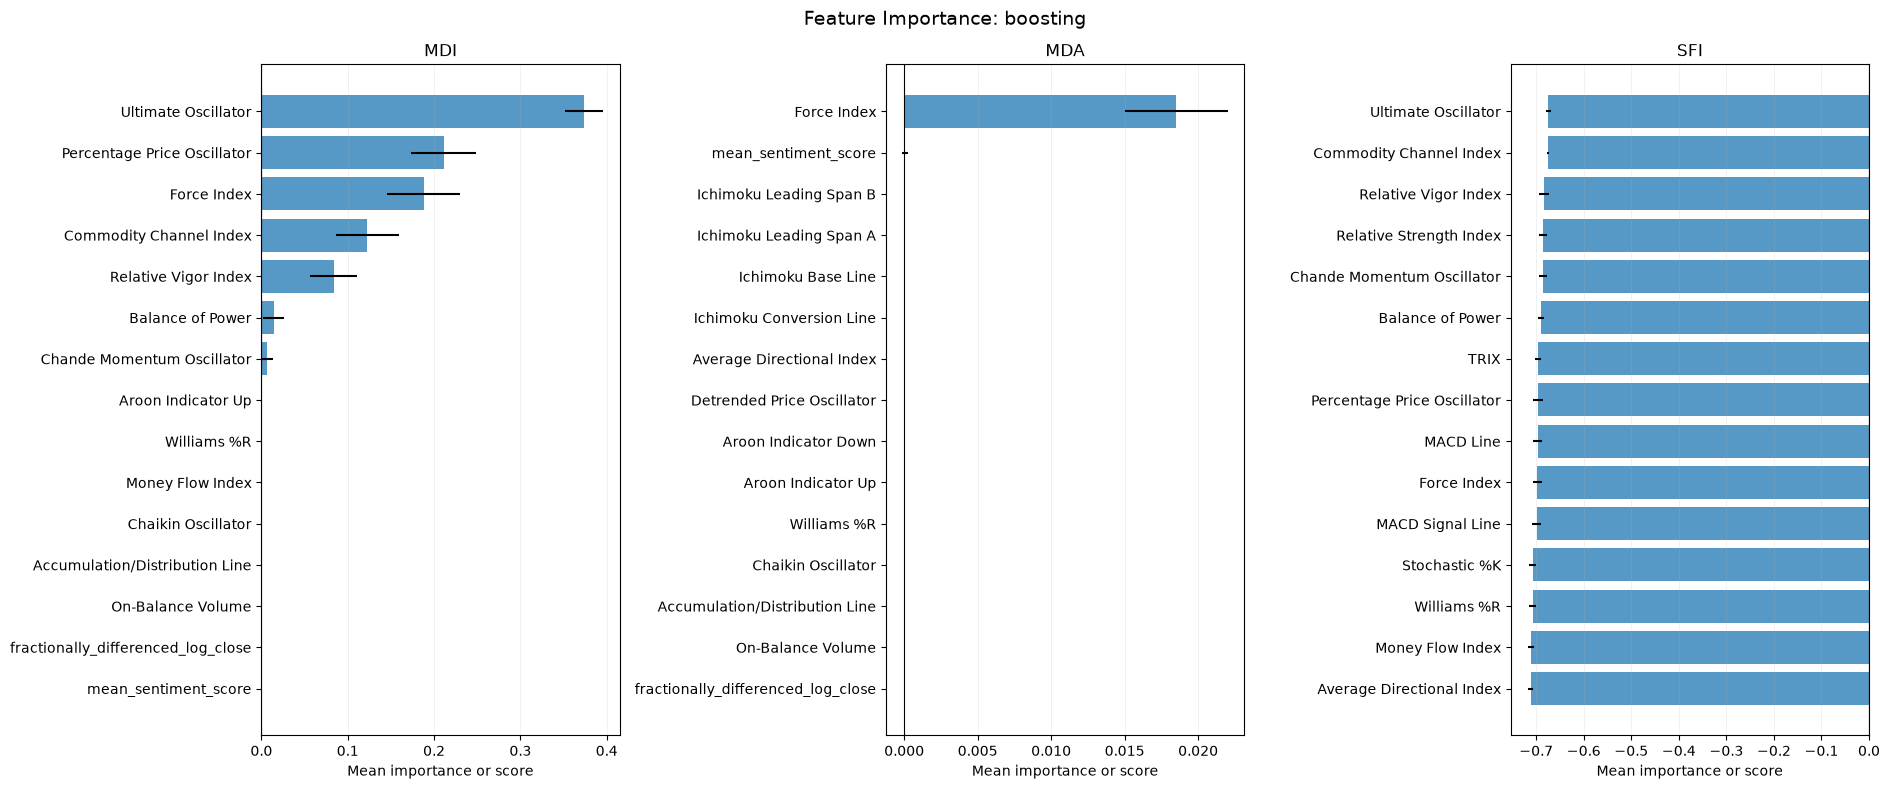

,mdi,mda,sfi_neg_log_loss
Force Index,0.187961,0.018520,-0.697856
mean_sentiment_score,0.000000,0.000082,-0.769126
Pivot Point Support 1,0.000000,0.000000,-0.718833
Exponential Moving Average (EMA),0.000000,0.000000,-0.723659
Double Exponential Moving Average (DEMA),0.000000,0.000000,-0.732041
Triangular Moving Average,0.000000,0.000000,-0.718827
Weighted Moving Average (WMA),0.000000,0.000000,-0.721232
Hull Moving Average (HMA),0.000000,0.000000,-0.736084
Volume Weighted Average Price (VWAP),0.000000,0.000000,-0.732700
Parabolic SAR,0.000000,0.000000,-0.720020


MDI importance:   0%|          | 0/6 [00:00<?, ?it/s]

MDA importance:   0%|          | 0/255 [00:00<?, ?it/s]

SFI importance:   0%|          | 0/255 [00:00<?, ?it/s]

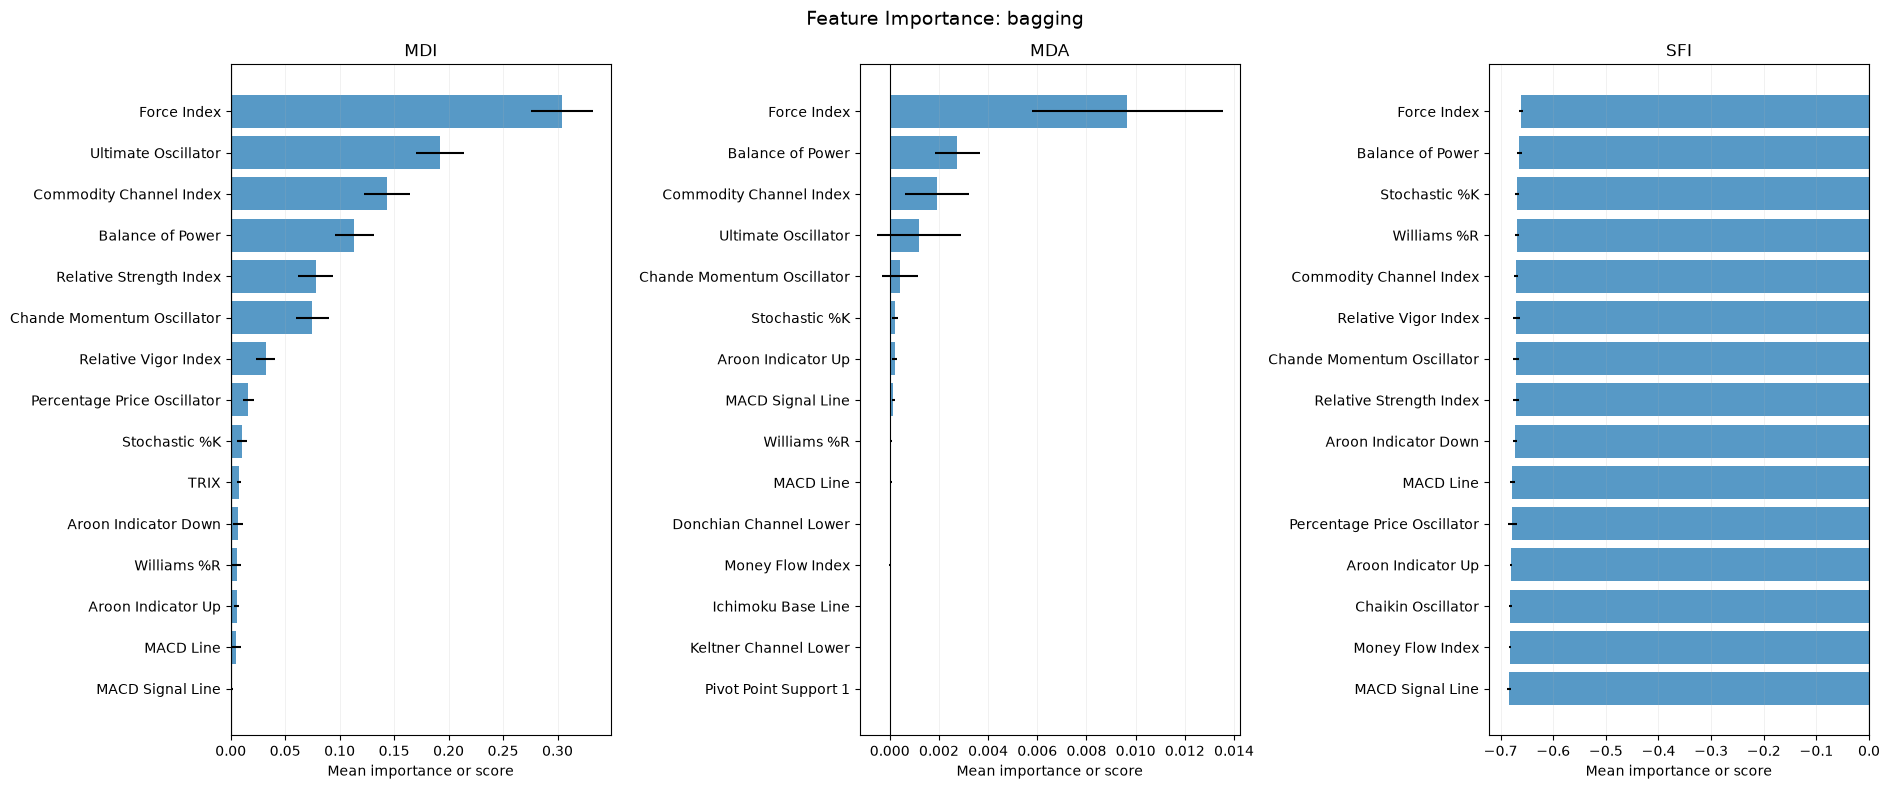

,mdi,mda,sfi_neg_log_loss
Force Index,0.303887,0.009658,-0.661286
Balance of Power,0.113534,0.002742,-0.664328
Commodity Channel Index,0.143763,0.001933,-0.669865
Ultimate Oscillator,0.192097,0.001194,-0.697702
Chande Momentum Oscillator,0.074993,0.000411,-0.670775
Stochastic %K,0.010368,0.000198,-0.669562
Aroon Indicator Up,0.005335,0.000194,-0.679700
MACD Signal Line,0.001040,0.000138,-0.684329
Williams %R,0.005373,0.000054,-0.669562
MACD Line,0.005261,0.000039,-0.677626


MDI importance:   0%|          | 0/6 [00:00<?, ?it/s]

MDA importance:   0%|          | 0/255 [00:00<?, ?it/s]

SFI importance:   0%|          | 0/255 [00:00<?, ?it/s]

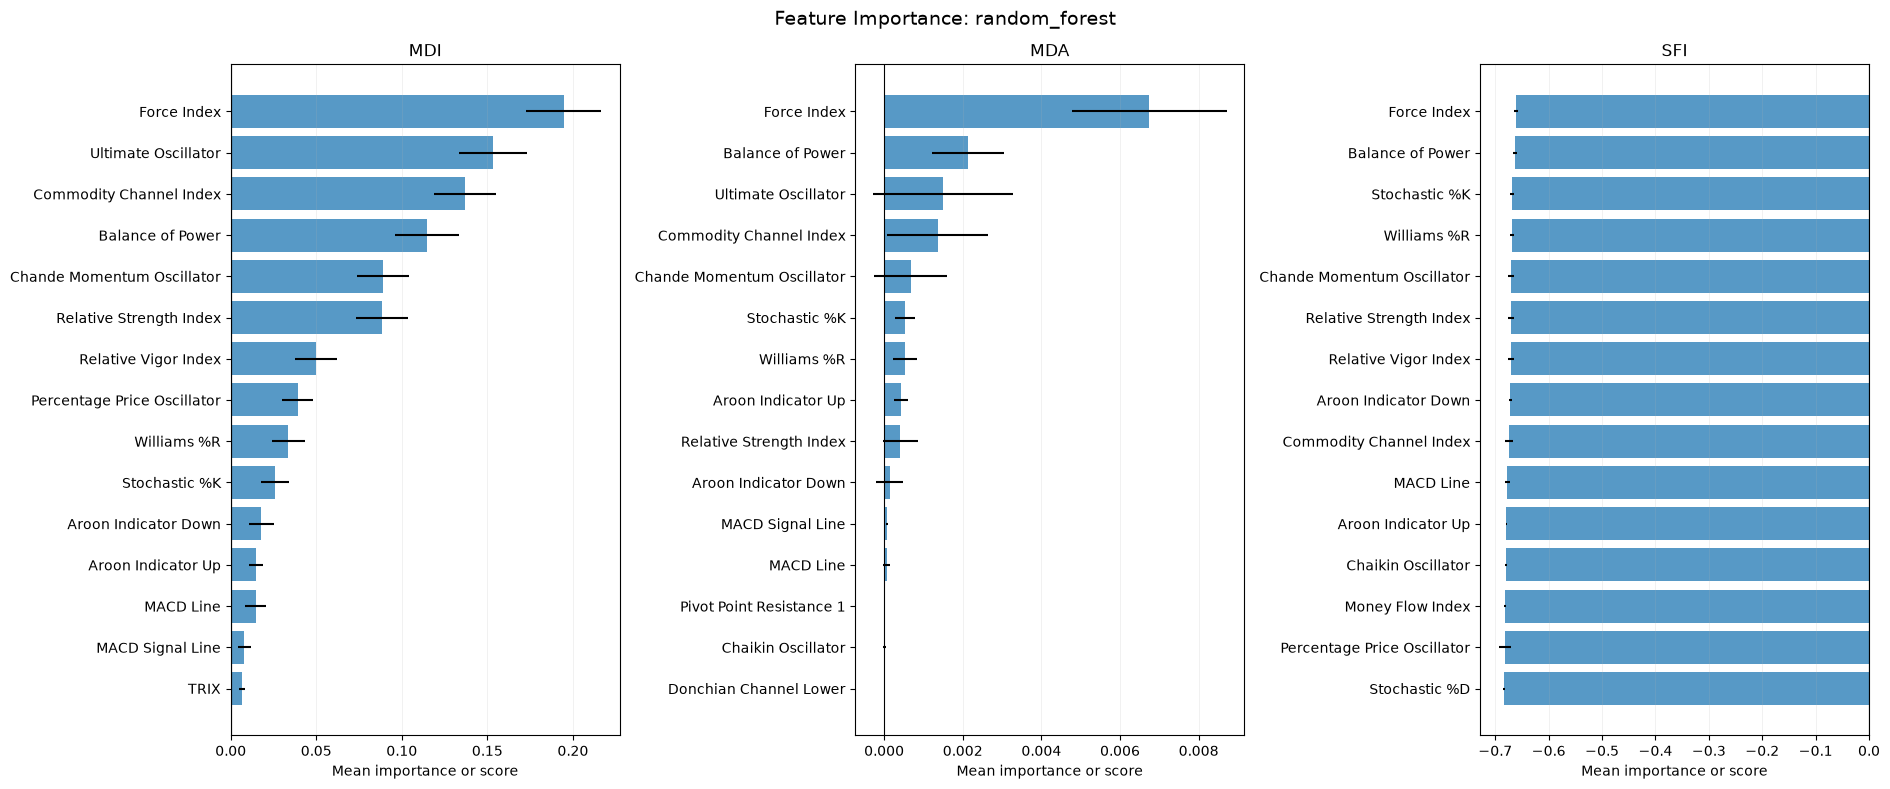

,mdi,mda,sfi_neg_log_loss
Force Index,0.194580,0.006745,-0.660757
Balance of Power,0.114854,0.002131,-0.663555
Ultimate Oscillator,0.153244,0.001504,-0.697597
Commodity Channel Index,0.137093,0.001364,-0.674832
Chande Momentum Oscillator,0.089027,0.000678,-0.670212
Stochastic %K,0.025842,0.000537,-0.668815
Williams %R,0.033702,0.000524,-0.668815
Aroon Indicator Up,0.014944,0.000428,-0.678978
Relative Strength Index,0.088548,0.000414,-0.670213
Aroon Indicator Down,0.017912,0.000147,-0.672156


,boosting,bagging,random_forest
MDI,-0.671587,-0.663063,-0.66202
MDA,-0.671587,-0.663063,-0.66202
SFI,-0.671587,-0.663063,-0.66202


In [4]:
importance_scores = {}
for name, estimator in candidates.items():
    results, scores = compute_stage_importance(
        estimator,
        features=X_development,
        labels=y_development,
        sample_weight=w_development,
        information_sets=t1_development,
        scoring=STAGE_SCORING,
        cv=CV_SPLITS,
        pct_embargo=PCT_EMBARGO,
        random_state=RANDOM_STATE,
        show_progress=True,
    )
    importance_scores[name] = scores
    plot_feature_importance(results, f"Feature Importance: {name}")
    importance = pd.DataFrame({
        "mdi": results["MDI"]["mean"],
        "mda": results["MDA"]["mean"],
        "sfi_neg_log_loss": results["SFI"]["mean"],
    }).sort_values("mda", ascending=False)
    display(importance.head(15))
display(pd.DataFrame(importance_scores))

## Model Evaluation

- **Purpose:** Compare each family’s best candidate’s accuracy, precision, recall, F1, log loss, and diagnostic curves on development OOF predictions; confusion matrices in one row and overlaid PR/ROC side by side.
- **Settings:** Labels = {-1, 1}; positive label = 1; sample-weighted metrics, confusion matrices, PR/AP and ROC/AUC.
- **Data:** Use development OOF results, then persist the model and prediction provenance.
- **Findings:**
- **Decision:** Fix the configuration from development OOF; holdout predictions are saved without displaying holdout evaluation.

,accuracy,precision,recall,f1,log_loss
model,,,,,
Boosting,0.614962,0.598465,0.640612,0.618822,0.670856
Bagging,0.614742,0.601460,0.623469,0.612267,0.662431
Random Forest,0.615115,0.597064,0.649298,0.622087,0.661509


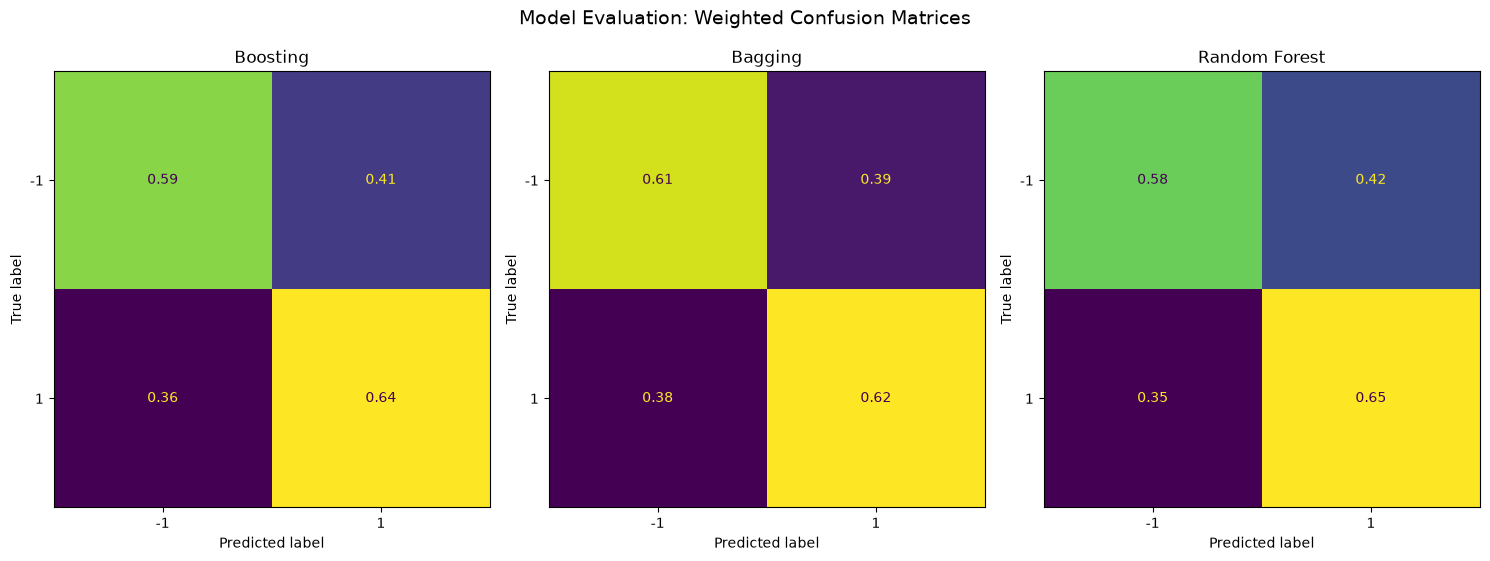

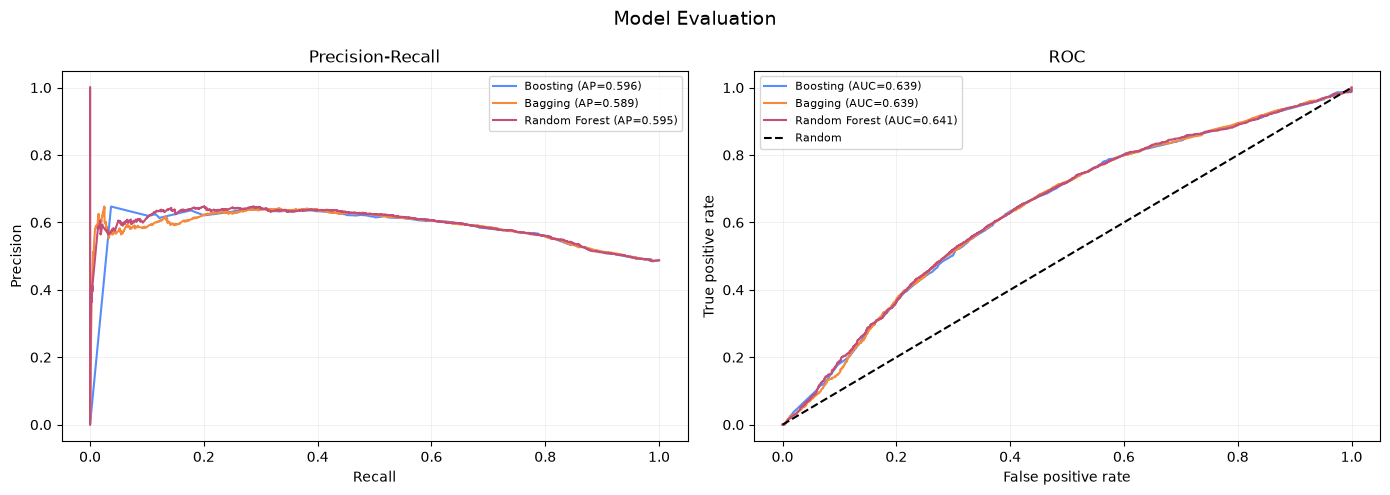

Final primary model:   0%|          | 0/4 [00:00<?, ?it/s]

/Users/kwonjunhyuk9/Documents/financial-machine-learning/data/modeling/sentiment/primary_model.joblib


In [6]:
display(build_model_evaluation_table(
    candidate_oof,
    y_development,
    w_development,
    class_labels=CLASS_LABELS,
    positive_label=1,
))

plot_model_evaluation(
    candidate_oof,
    y_development,
    w_development,
    "Model Evaluation",
    class_labels=CLASS_LABELS,
    positive_label=1,
)

primary_predictions = finalize_primary_model(
    development,
    holdout,
    estimator=final_estimator,
    final_oof=final_oof,
    feature_columns=feature_columns,
    artifact_dir=artifact_dir,
    selected_candidate=final_name,
    best_configuration=final_configuration,
    random_state=RANDOM_STATE,
    show_progress=True,
)

print(artifact_dir / "primary_model.joblib")